# 초기 100사이클 배터리 수명 예측 — EDA

원본 139셀을 보존한다. `cycle_life`가 제공된 셀만 수명 회귀의 학습·평가에 사용한다. 제공 라벨이 관측 길이+1 이상이며 최종 QD가 0.885 Ah보다 높은 경우 우측 검열로 표시한다. 관측 종료 사이클을 수명으로 대체하지 않는다. Batch 1 중도 종료 10셀, Batch 2 라벨 결측 8셀, Batch 3 결측 2셀은 타깃 분석에서 제외한다. 이 제외는 예측 오차가 아니라 원본 라벨 존재 여부에 따른다.

In [5]:
from pathlib import Path
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
project = Path.cwd() if (Path.cwd() / 'src').is_dir() else Path.cwd().parent
sys.path.insert(0, str(project))
from src.features import load_cells, feature_matrix
from src.preprocess import DQ_FEATURES, policy_holdout, grouped_cv
cells = load_cells()
labelled = cells[cells.label_status == 'provided'].copy()

plt.rcParams.update({'font.size': 13, 'axes.titlesize': 16, 'axes.labelsize': 14, 'xtick.labelsize': 12, 'ytick.labelsize': 12, 'legend.fontsize': 12, 'figure.dpi': 140, 'savefig.dpi': 200})
figure_dir = project / 'results' / 'figures'
figure_dir.mkdir(parents=True, exist_ok=True)

## 라벨 감사

`label_status=missing`은 측정 종료 시점만 알려져 정확한 수명 MAPE를 계산할 수 없는 셀이다. 일부 유효한 제공 라벨도 종료 조건에 대한 추가 검증이 필요할 수 있으므로, 이 결과를 저자 전처리 124셀 실험의 재현이라고 해석하지 않는다.

,total_cells,labelled_cells,excluded_targets
batch,,,
Batch 1,46,36,10
Batch 2,47,39,8
Batch 3,46,44,2


,cell_id,label_status,cycle_life,n_cycles,last_QD
0,Batch 1-0,right_censored,NaN,1189,1.026210
1,Batch 1-1,right_censored,NaN,1178,1.038225
2,Batch 1-2,right_censored,NaN,1176,1.043279
3,Batch 1-3,right_censored,NaN,1225,0.970921
4,Batch 1-4,right_censored,NaN,1226,1.021960
8,Batch 1-8,right_censored,NaN,878,0.969025
10,Batch 1-10,right_censored,NaN,905,0.961019
12,Batch 1-12,right_censored,NaN,901,0.913119
13,Batch 1-13,right_censored,NaN,896,0.923136
22,Batch 1-22,right_censored,NaN,890,0.963279


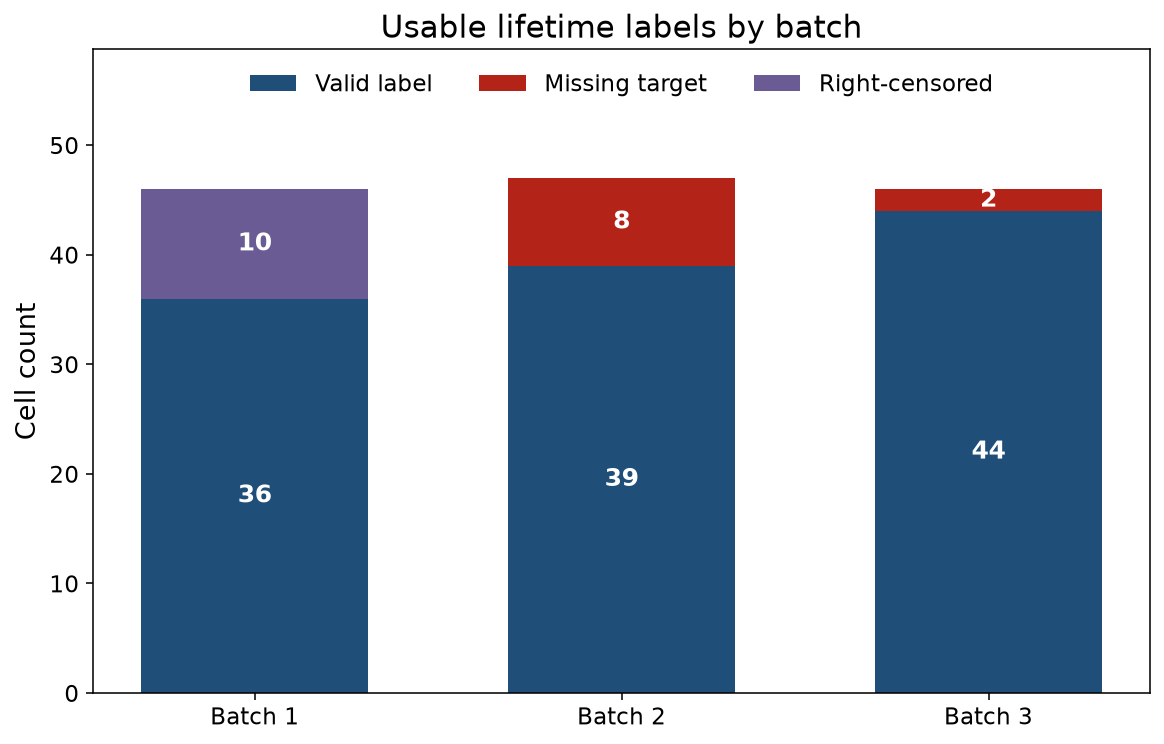

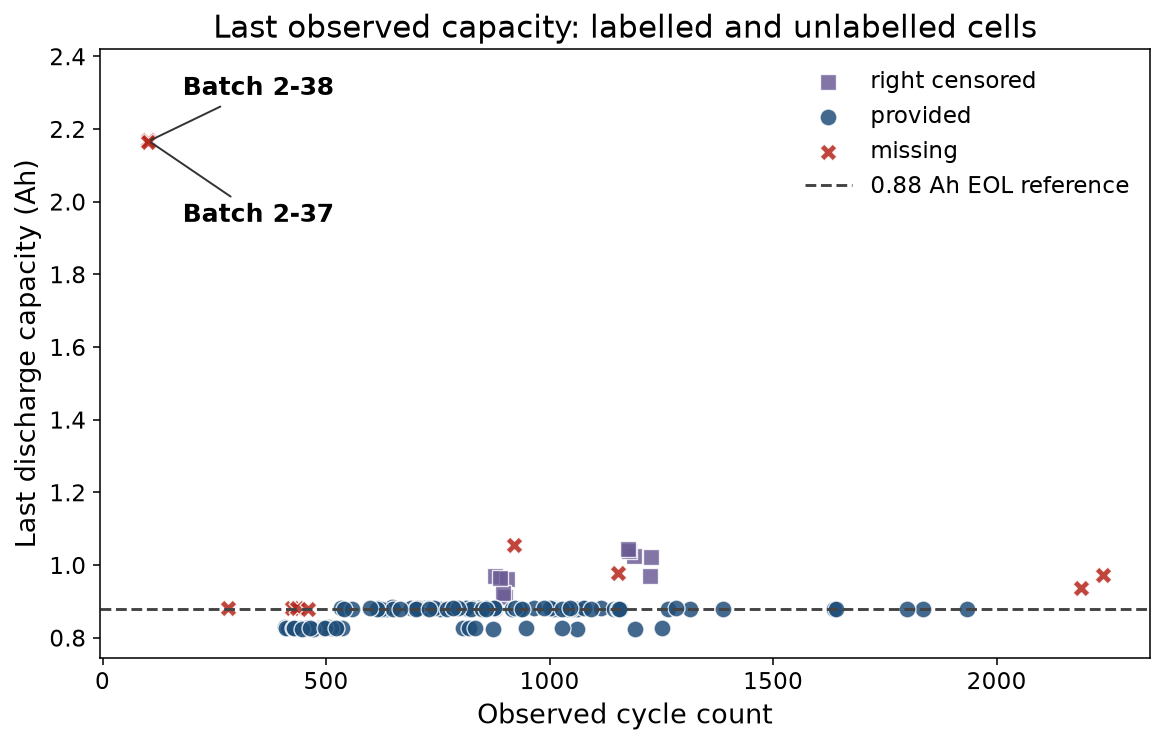

In [6]:
audit = cells.groupby('batch').agg(total_cells=('cell_id','size'), labelled_cells=('cycle_life','count'))
audit['excluded_targets'] = audit.total_cells - audit.labelled_cells
display(audit)
display(cells[cells.label_status != 'provided'][['cell_id','label_status','cycle_life','n_cycles','last_QD']])
colors = {'provided':'#1f4e79','missing':'#b42318','right_censored':'#6b5b95'}
batches = ['Batch 1','Batch 2','Batch 3']
fig, ax = plt.subplots(figsize=(8.2,5.2), constrained_layout=True)
bottom = np.zeros(3)
for status, label in [('provided','Valid label'),('missing','Missing target'),('right_censored','Right-censored')]:
    values = np.array([(cells.batch.eq(batch) & cells.label_status.eq(status)).sum() for batch in batches])
    bars = ax.bar(batches,values,bottom=bottom,color=colors[status],label=label,width=.62)
    for rect,value,start in zip(bars,values,bottom):
        if value: ax.text(rect.get_x()+rect.get_width()/2,start+value/2,str(value),ha='center',va='center',color='white',fontweight='bold')
    bottom += values
ax.set(ylabel='Cell count',title='Usable lifetime labels by batch',ylim=(0,max(bottom)*1.25))
ax.legend(frameon=False,loc='upper center',bbox_to_anchor=(.5,.995),ncol=3); ax.grid(axis='x',visible=False)
fig.savefig(figure_dir/'fig1a_label_status.png',dpi=200,bbox_inches='tight'); plt.show()
fig, ax = plt.subplots(figsize=(8.2,5.2),constrained_layout=True)
markers={'provided':'o','missing':'X','right_censored':'s'}
for status,part in cells.groupby('label_status',sort=False):
    ax.scatter(part.n_cycles,part.last_QD,s=76,alpha=.84,marker=markers[status],color=colors[status],edgecolor='white',linewidth=.7,label=status.replace('_',' '))
ax.axhline(.88,ls='--',color='#444444',lw=1.5,label='0.88 Ah EOL reference')
for cell_id, offset in [('Batch 2-37',(18,-42)),('Batch 2-38',(18,24))]:
    row = cells.loc[cells.cell_id == cell_id].iloc[0]
    ax.annotate(cell_id,(row.n_cycles,row.last_QD),xytext=offset,textcoords='offset points',fontsize=13,fontweight='bold',arrowprops={'arrowstyle':'-','color':'#333333'})
ax.set(xlabel='Observed cycle count',ylabel='Last discharge capacity (Ah)',title='Last observed capacity: labelled and unlabelled cells')
ax.set_ylim(min(.78,cells.last_QD.min()-.08),cells.last_QD.max()+.25); ax.legend(frameon=False,loc='upper right')
fig.savefig(figure_dir/'fig1b_end_capacity.png',dpi=200,bbox_inches='tight'); plt.show()

## 수명 분포와 배치 이동

라벨이 없는 101사이클 관측 셀을 단수명 셀로 세지 않는다. Batch 2는 라벨이 있는 셀에서도 학습 배치보다 수명이 짧다.

,count,mean,min,max
batch,,,,
Batch 1,36,788.416667,534.0,1074.0
Batch 2,39,565.743590,392.0,1186.0
Batch 3,44,1059.659091,541.0,1935.0


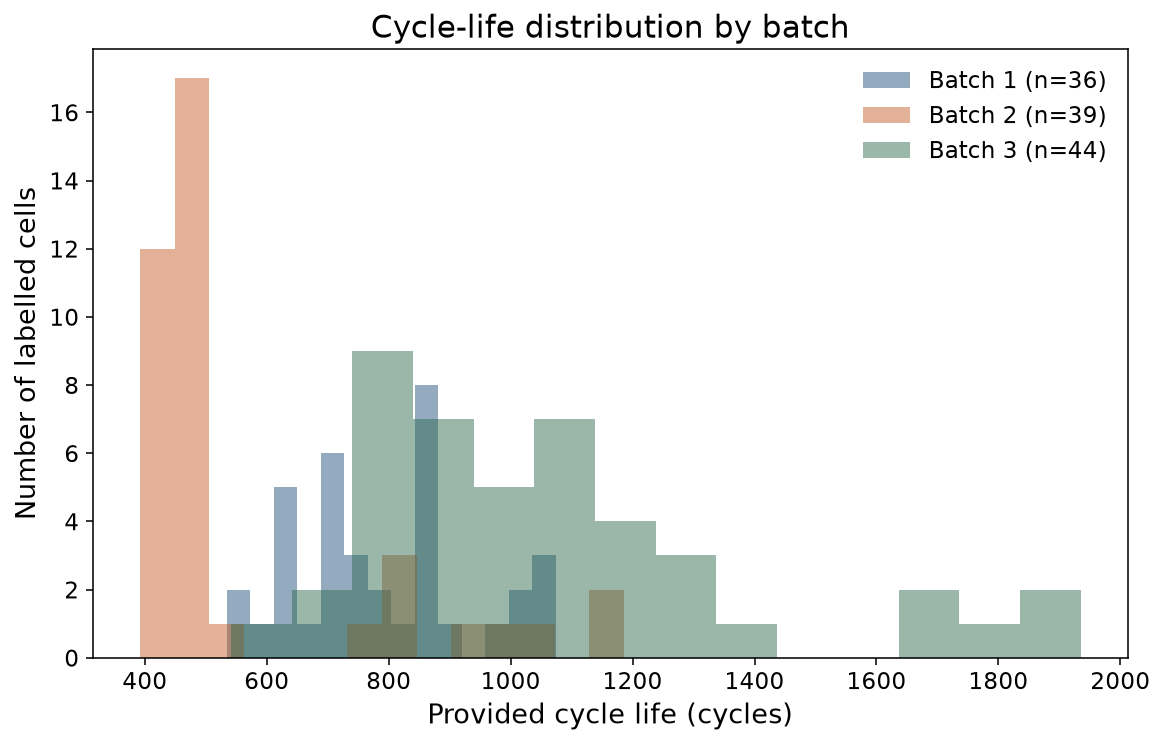

In [7]:
display(labelled.groupby('batch').cycle_life.agg(['count','mean','min','max']))
fig, ax = plt.subplots(figsize=(8.2,5.2),constrained_layout=True)
for batch,part in labelled.groupby('batch'):
    ax.hist(part.cycle_life,bins=14,alpha=.48,color={'Batch 1':'#1f4e79','Batch 2':'#c45c26','Batch 3':'#2d6a4f'}[batch],label=f'{batch} (n={len(part)})')
ax.set(xlabel='Provided cycle life (cycles)',ylabel='Number of labelled cells',title='Cycle-life distribution by batch')
ax.legend(frameon=False); plt.show()

## ΔQ와 충전 정책

ΔQ는 모든 셀에서 `Qdlin(cycle=100) − Qdlin(cycle=10)`이다. 초기 용량과 관측 총 길이를 수명 대신 사용하지 않는다.

,,cycle_life,dq_var,dq_min,dq_mean,mean_chargetime,mean_Tavg
batch,,,,,,,
Batch 1,cycle_life,1.0,-0.801105,0.805061,0.767550,0.489712,-0.172708
Batch 2,cycle_life,1.0,-0.732787,0.818518,0.767085,0.087033,0.424616
Batch 3,cycle_life,1.0,-0.589654,0.692116,0.639115,0.637495,-0.021817


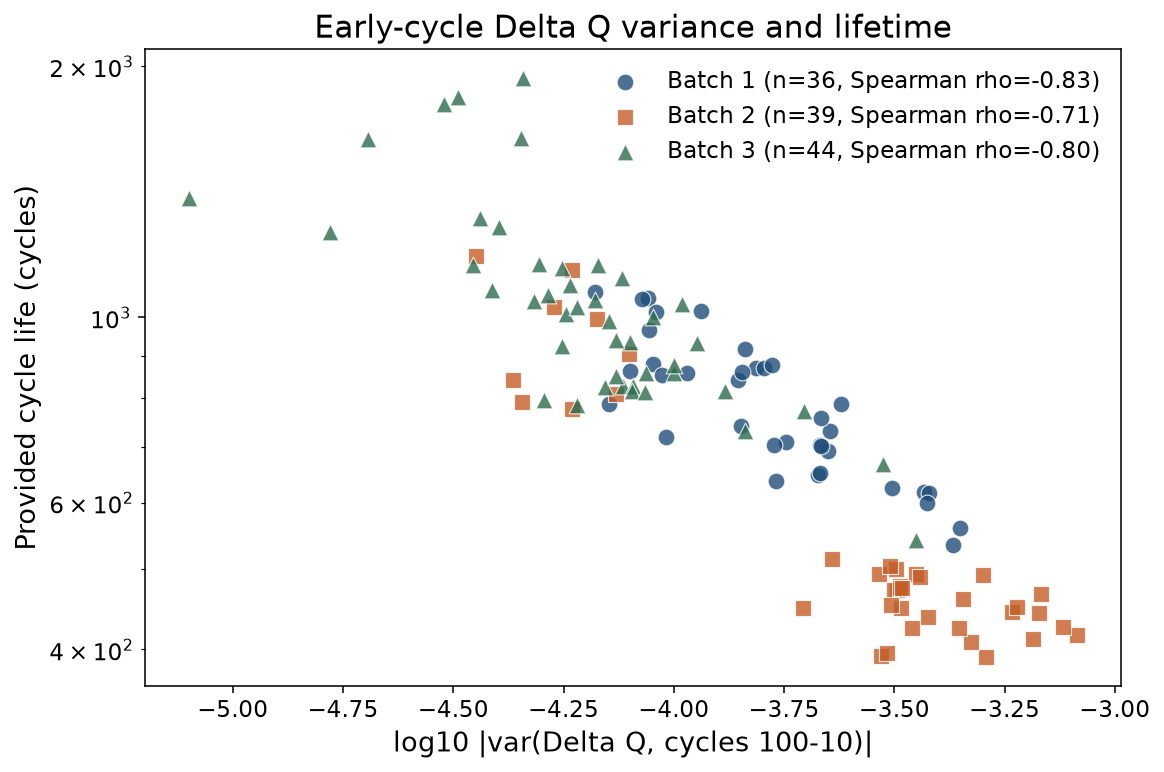

count     mean
batch   charging_policy                            
Batch 1 4.4C(80%)-4.4C                   1  1074.00
        4.8C(80%)-4.8C                   2   753.00
        5.4C(40%)-3.6C                   1  1054.00
        5.4C(50%)-3C                     1   788.00
        5.4C(60%)-3.6C                   2   859.50
        5.4C(60%)-3C                     2   799.50
        5.4C(70%)-3C                     2   739.50
        5.4C(80%)-5.4C                   2   546.50
        6C(30%)-3.6C                     1  1014.00
        6C(40%)-3.6C                     2   856.00
        6C(40%)-3C                       2   935.50
        6C(50%)-3.6C                     2   792.50
        6C(50%)-3C                       2   888.50
        6C(60%)-3C                       2   744.00
        7C(30%)-3.6C                     2   722.50
        7C(40%)-3.6C                     2   621.00
        7C(40%)-3C                       2   676.00
        8C(15%)-3.6C                     2  1008.50
        8C(25%)-3.6C                     2   676.50
        8C(35%)-3.6C                     2   607.50
Batch 2 3.6C(30%)-6C                     2   421.00
        3.6C(9%)-5C                      2   394.50
        4.65C(44%)-5C                    2   482.50
        4.65C(69%)-6C                    2   452.00
        4.8C(80%)-4.8C                   5   483.60
        4.8C(80%)-4.8C-newstructure      3   871.67
        5.2C(50%)-4.25C                  5   454.00
        5.2C(58%)-4C                     4   477.75
        5.2C(58%)-4C-newstructure        3   961.67
        5.6C(26%)-4.5C                   6   448.50
        5.6C(26%)-4.5C-newstructure      3   991.33
        6C(60%)-3C                       2   400.00
Batch 3 3.7C(31%)-5.9C-newstructure      3   660.00
        4.8C(80%)-4.8C-newstructure      6  1564.17
        5.3C(54%)-4C-newstructure        8  1074.38
        5.6C(19%)-4.6C-newstructure      8  1001.38
        5.6C(36%)-4.3C-newstructure      8   930.88
        5.9C(15%)-4.6C-newstructure      2   867.00
        5.9C(60%)-3.1C-newstructure      2   866.50
        5C(67%)-4C-newstructure          7  1105.71

In [8]:
corr = labelled.groupby('batch')[['cycle_life'] + DQ_FEATURES + ['mean_chargetime','mean_Tavg']].corr()
display(corr.loc[(slice(None),'cycle_life'),:])
fig, ax = plt.subplots(figsize=(8.2,5.4),constrained_layout=True)
markers={'Batch 1':'o','Batch 2':'s','Batch 3':'^'}
colors={'Batch 1':'#1f4e79','Batch 2':'#c45c26','Batch 3':'#2d6a4f'}
for batch,part in labelled.groupby('batch'):
    x=np.log10(np.maximum(np.abs(part.dq_var),1e-15))
    rho=x.corr(part.cycle_life,method='spearman')
    ax.scatter(x,part.cycle_life,s=74,alpha=.8,marker=markers[batch],color=colors[batch],edgecolor='white',linewidth=.6,label=f'{batch} (n={len(part)}, Spearman rho={rho:.2f})')
ax.set(xlabel='log10 |var(Delta Q, cycles 100-10)|',ylabel='Provided cycle life (cycles)',yscale='log',title='Early-cycle Delta Q variance and lifetime')
ax.legend(frameon=True,facecolor='white',edgecolor='none',loc='best')
fig.savefig(figure_dir/'fig2_dq_vs_life.png',dpi=200,bbox_inches='tight'); plt.show()
display(labelled.groupby(['batch','charging_policy']).cycle_life.agg(['count','mean']).round(2))

## 수정된 모델 전략

타깃은 `cycle_life` 회귀다. ΔQ 3개를 중심으로 원수명·로그 수명과 ΔQ 로그 통계 후보를 비교한다. MAPE 목적에 맞춰 내부 튜닝을 수행한다. Batch 1 정책 Hold-out으로 후보를 선택하며, 학습 분할 안의 외부·내부 CV도 정책 단위로 분리한다. Batch 2의 타깃 결측은 보간하지 않는다.

이미 Batch 2 결과를 보고 오류를 진단하며 전략을 수정한 개발 실험이다. 새로운 블라인드 테스트라고 주장하지 않는다. 최종 후보 선택 함수는 Batch 1 Hold-out MAPE만 사용한다.